# C — Albedo vs Surface Temperature Regression
Tests whether higher albedo correlates with lower surface temperatures.
Shows scatter plots with OLS regression line, R² and slope per area/season.

**Saves to** `../figures/C_albedo_regression/`

In [1]:
import sys
from pathlib import Path
NB_DIR = Path.cwd() if Path.cwd().name == 'notebooks' else Path.cwd() / 'notebooks'
sys.path.insert(0, str(NB_DIR))
from config import *
from scipy import stats

SAVE_DIR = FIGURES_DIR / 'C_albedo_regression'
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print('Setup done. Saving to:', SAVE_DIR)

Config loaded.  ROOT=/home/mourouzidou/Downloads/Anastasia
Output dir : /home/mourouzidou/Downloads/Anastasia/output
Figures dir: /home/mourouzidou/Downloads/Anastasia/figures
Setup done. Saving to: /home/mourouzidou/Downloads/Anastasia/figures/C_albedo_regression


In [2]:
print('Loading surface...'); srf_raw = load_csvs('surface')
SURF_TEMP_COL, SURF_ALB_COL = detect_surface_cols(srf_raw)
print(f'Surface temp col : {SURF_TEMP_COL}')
print(f'Surface albedo col: {SURF_ALB_COL}')
srf = srf_raw.copy()

Loading surface...
  Shaded_15Aug_surface.parquet  →  250,000 rows
  Shaded_15Feb_surface.parquet  →  250,000 rows
  Shaded_15Nov_surface.parquet  →  250,000 rows
  Shaded_31Mar_surface.parquet  →  250,000 rows
  Waterfront_15Aug_surface.parquet  →  250,000 rows
  Waterfront_15Feb_surface.parquet  →  250,000 rows
  Waterfront_15Nov_surface.parquet  →  250,000 rows
  Waterfront_31Mar_surface.parquet  →  250,000 rows
  Zefkseidos_15Aug_surface.parquet  →  290,000 rows
  Zefkseidos_15Feb_surface.parquet  →  250,000 rows
  Zefkseidos_15Nov_surface.parquet  →  250,000 rows
  Zefkseidos_31Mar_surface.parquet  →  250,000 rows
Surface temp col : T Surface (°C)
Surface albedo col: Surface Albedo ()


## C1 — Scatter + regression: 3×4 grid (area × date) at peak hour (13:00)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

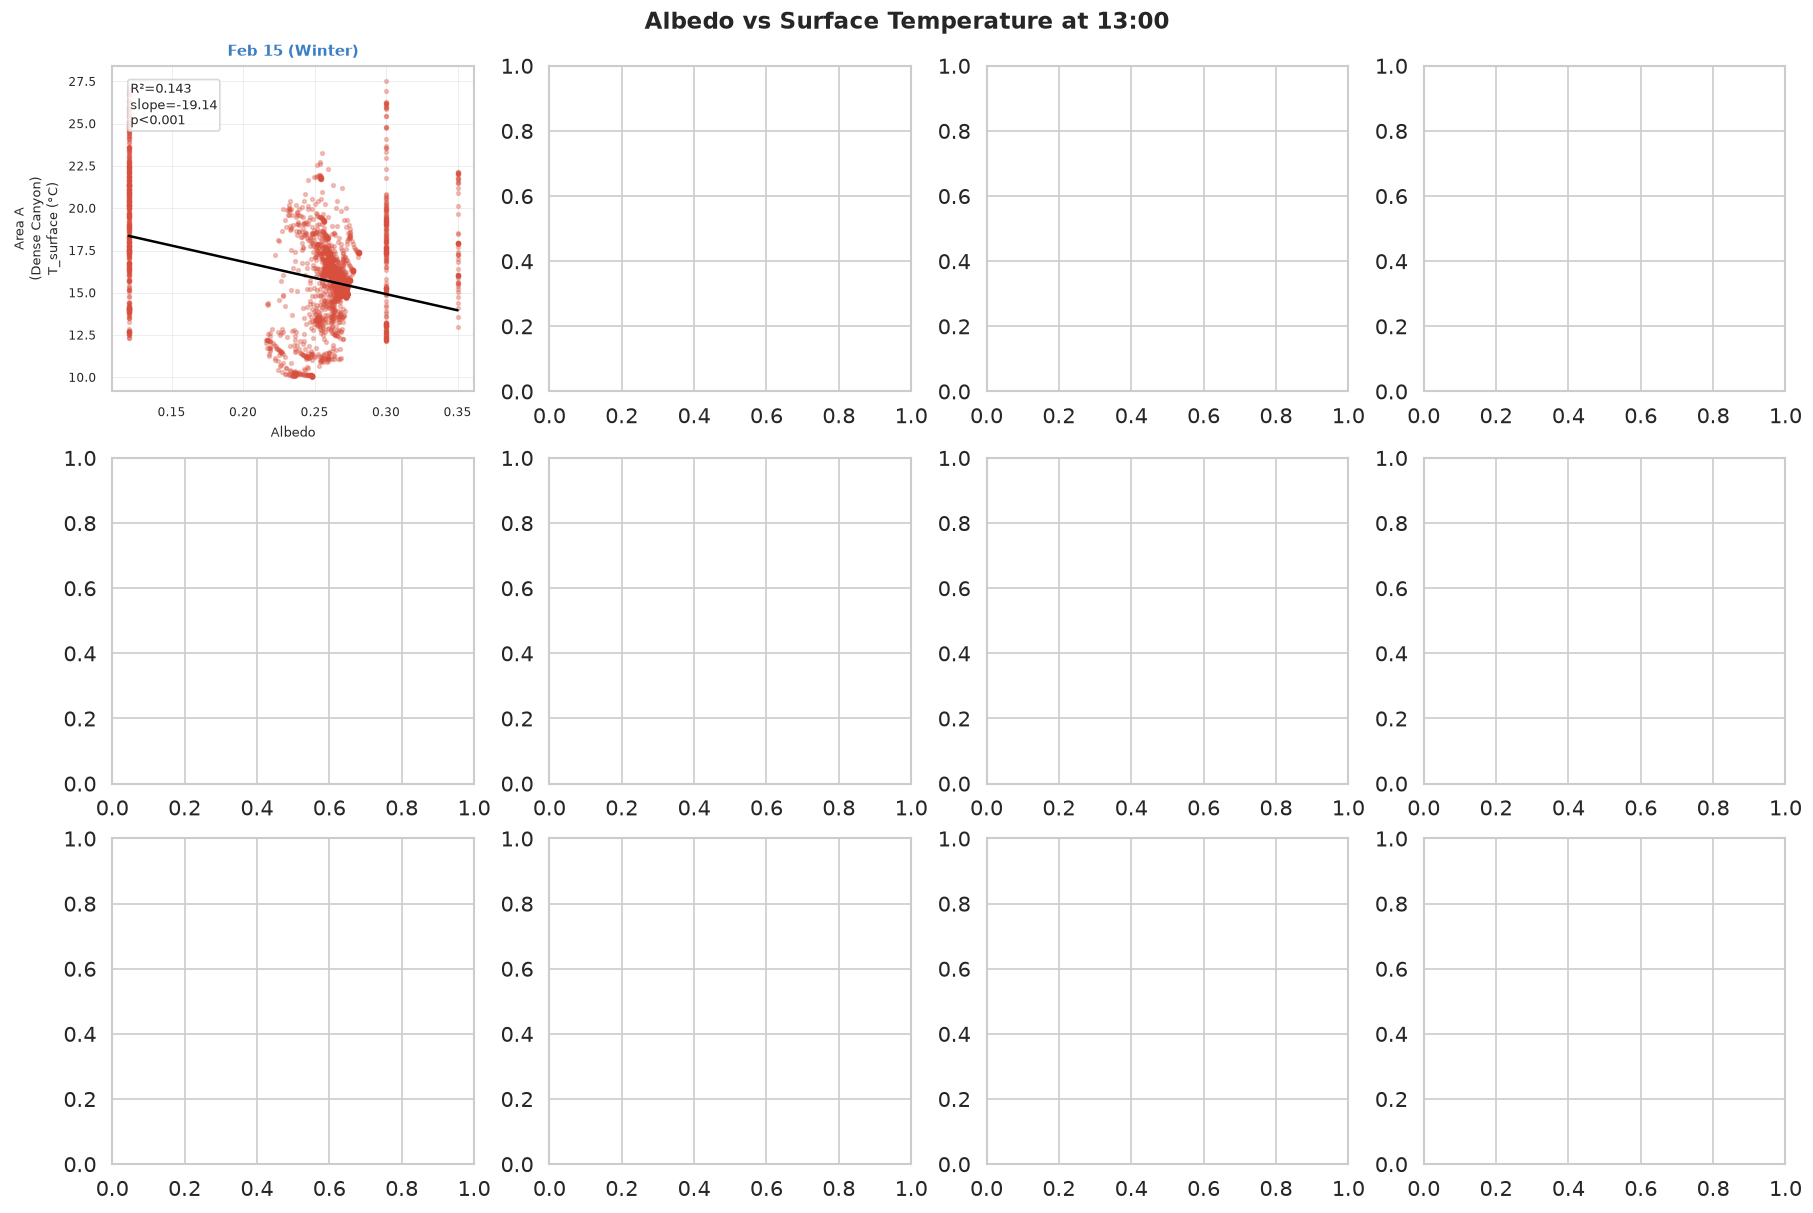

In [3]:
if SURF_ALB_COL is None:
    print('No albedo column found — skipping C1.')
else:
    PEAK_H = 13
    srf13 = srf[srf['hour'] == PEAK_H]

    fig, axes = plt.subplots(len(AREA_ORDER), len(DATE_ORDER), figsize=(15, 10),
                             constrained_layout=True)
    fig.suptitle(f'Albedo vs Surface Temperature at {PEAK_H}:00', fontsize=14, fontweight='bold')

    for r, area in enumerate(AREA_ORDER):
        for c, date in enumerate(DATE_ORDER):
            ax = axes[r, c]
            if r == 0: ax.set_title(DATE_LABELS[date], fontsize=9, fontweight='bold', color=DATE_COLORS[date])
            if c == 0: ax.set_ylabel(AREA_LABELS[area] + '\nT_surface (°C)', fontsize=8)
            ax.set_xlabel('Albedo', fontsize=8)

            sub = srf13[(srf13['area'] == area) & (srf13['date'] == date)][[SURF_ALB_COL, SURF_TEMP_COL]].dropna()
            if len(sub) < 5:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes, color='grey')
                continue

            x, y = sub[SURF_ALB_COL].values, sub[SURF_TEMP_COL].values
            slope, intercept, r, p, _ = stats.linregress(x, y)
            color = AREA_COLORS[area]

            ax.scatter(x, y, color=color, alpha=0.3, s=5, rasterized=True)
            xfit = np.linspace(x.min(), x.max(), 100)
            ax.plot(xfit, slope * xfit + intercept, color='black', lw=1.5)

            pstr = f'p<0.001' if p < 0.001 else f'p={p:.3f}'
            ax.text(0.05, 0.95,
                    f'R²={r**2:.3f}\nslope={slope:.2f}\n{pstr}',
                    transform=ax.transAxes, fontsize=7.5, va='top',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='lightgrey', alpha=0.85))
            ax.tick_params(labelsize=7)
            ax.grid(lw=0.4, alpha=0.5)

    fig.savefig(SAVE_DIR / 'C1_albedo_vs_Tsurf_grid.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved C1')

## C2 — Albedo stability: box plots across hours (does albedo vary intraday?)

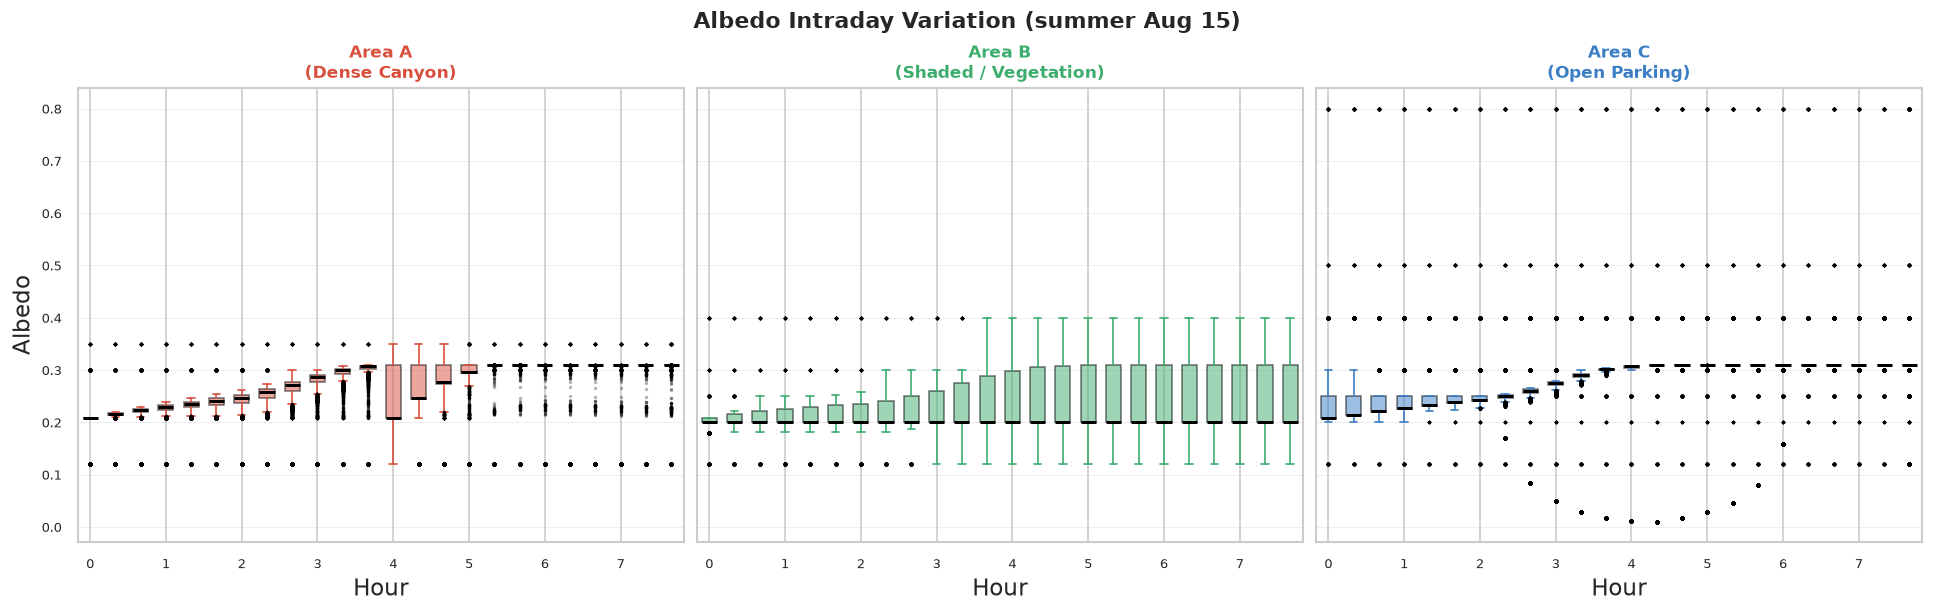

Saved C2


In [4]:
if SURF_ALB_COL is None:
    print('No albedo column — skipping C2.')
else:
    fig, axes = plt.subplots(1, len(AREA_ORDER), figsize=(16, 5), sharey=True, constrained_layout=True)
    fig.suptitle('Albedo Intraday Variation (summer Aug 15)', fontsize=13, fontweight='bold')

    for ax, area in zip(axes, AREA_ORDER):
        ax.set_title(AREA_LABELS[area], fontsize=10, fontweight='bold', color=AREA_COLORS[area])
        ax.set_xlabel('Hour'); ax.set_ylabel('Albedo') if area == AREA_ORDER[0] else None
        sub = srf[(srf['area'] == area) & (srf['date'] == '15Aug')][[SURF_ALB_COL, 'hour']].dropna()
        if len(sub) == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            continue
        hrs = sorted(sub['hour'].unique())
        data = [sub[sub['hour'] == h][SURF_ALB_COL].values for h in hrs]
        bp = ax.boxplot(data, positions=hrs, widths=0.6, patch_artist=True,
                        boxprops=dict(facecolor=AREA_COLORS[area], alpha=0.5),
                        medianprops=dict(color='black', lw=1.8),
                        flierprops=dict(marker='.', markersize=2, alpha=0.3),
                        whiskerprops=dict(color=AREA_COLORS[area]),
                        capprops=dict(color=AREA_COLORS[area]))
        ax.set_xticks(range(0, 24, 3))
        ax.tick_params(labelsize=8)
        ax.grid(axis='y', lw=0.4, alpha=0.5)

    fig.savefig(SAVE_DIR / 'C2_albedo_intraday.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved C2')

## C3 — Albedo vs T_surface: pooled across all hours, coloured by season

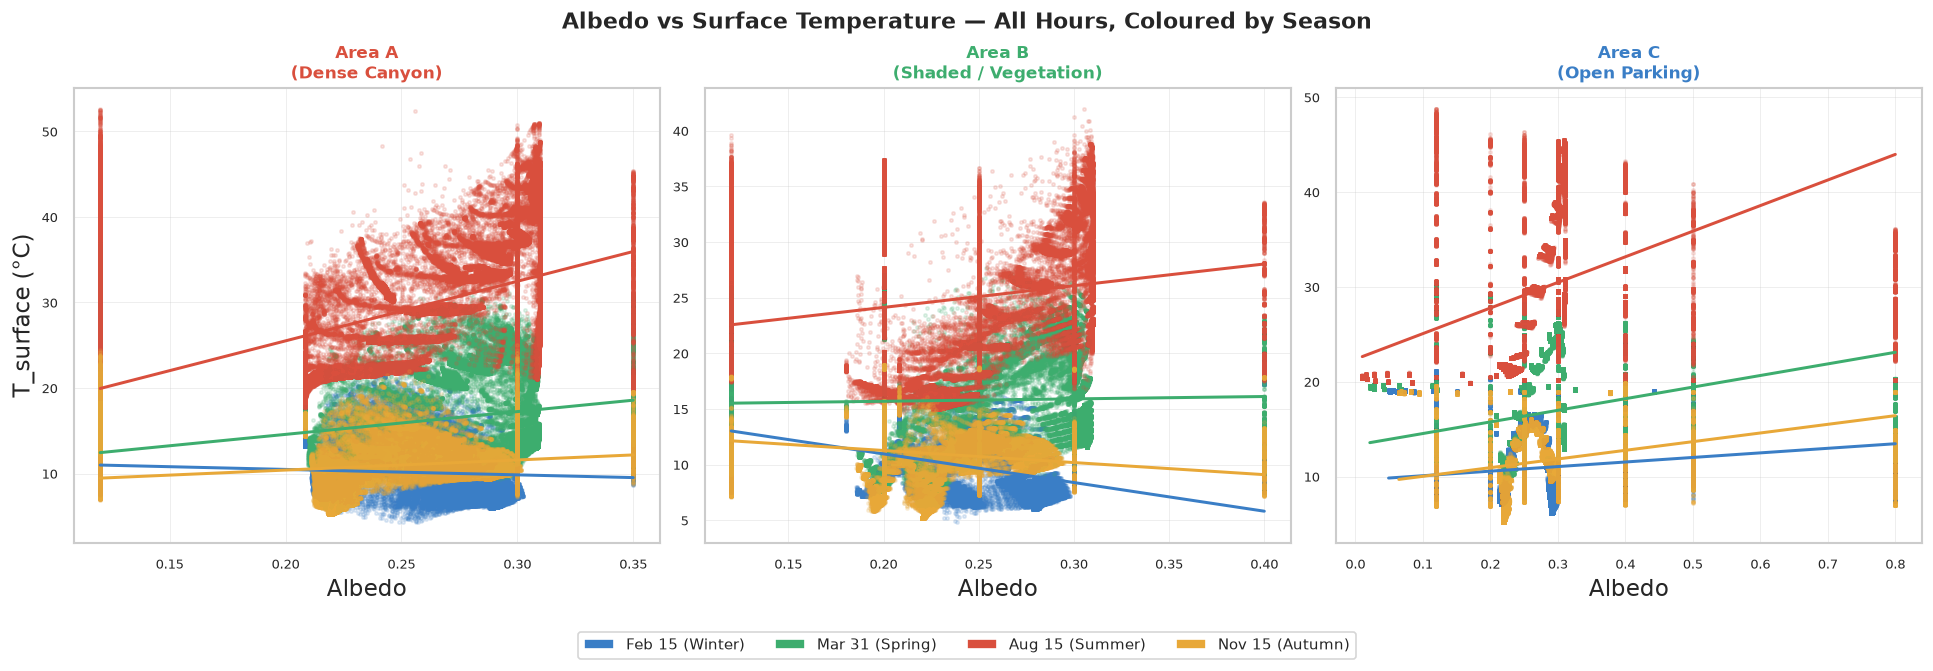

Saved C3


In [5]:
if SURF_ALB_COL is None:
    print('No albedo column — skipping C3.')
else:
    fig, axes = plt.subplots(1, len(AREA_ORDER), figsize=(16, 5), constrained_layout=True)
    fig.suptitle('Albedo vs Surface Temperature — All Hours, Coloured by Season', fontsize=13, fontweight='bold')
    import matplotlib.patches as mpatches

    for ax, area in zip(axes, AREA_ORDER):
        ax.set_title(AREA_LABELS[area], fontsize=10, fontweight='bold', color=AREA_COLORS[area])
        ax.set_xlabel('Albedo')
        if area == AREA_ORDER[0]: ax.set_ylabel('T_surface (°C)')

        for date in DATE_ORDER:
            sub = srf[(srf['area'] == area) & (srf['date'] == date)][[SURF_ALB_COL, SURF_TEMP_COL]].dropna()
            if len(sub) < 5: continue
            ax.scatter(sub[SURF_ALB_COL], sub[SURF_TEMP_COL],
                       color=DATE_COLORS[date], alpha=0.15, s=4, rasterized=True)
            # per-season regression
            x, y = sub[SURF_ALB_COL].values, sub[SURF_TEMP_COL].values
            slope, intercept, r, p, _ = stats.linregress(x, y)
            xfit = np.linspace(x.min(), x.max(), 80)
            ax.plot(xfit, slope * xfit + intercept, color=DATE_COLORS[date], lw=1.8)

        ax.grid(lw=0.4, alpha=0.5)
        ax.tick_params(labelsize=8)

    legend_patches = [mpatches.Patch(facecolor=DATE_COLORS[d], label=DATE_LABELS[d]) for d in DATE_ORDER]
    fig.legend(handles=legend_patches, loc='upper center', ncol=4, fontsize=9,
               bbox_to_anchor=(0.5, -0.03), frameon=True)
    fig.savefig(SAVE_DIR / 'C3_albedo_Tsurf_pooled.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved C3')

## C4 — Regression summary table

In [ ]:
if SURF_ALB_COL is None:
    print('No albedo column found in surface data.')
else:
    PEAK_H = 13
    rows = []
    for area in AREA_ORDER:
        for date in DATE_ORDER:
            sub = srf[(srf['area'] == area) & (srf['date'] == date) & (srf['hour'] == PEAK_H)][
                [SURF_ALB_COL, SURF_TEMP_COL]].dropna()
            if len(sub) < 5: continue
            x, y = sub[SURF_ALB_COL].values, sub[SURF_TEMP_COL].values
            slope, intercept, r, p, _ = stats.linregress(x, y)
            rows.append({'Area': area, 'Date': date, 'N': len(sub),
                         'Slope': round(slope, 3), 'R²': round(r**2, 4),
                         'p': f'{p:.4f}' if p >= 0.0001 else '<0.0001'})
    reg_df = pd.DataFrame(rows)
    print(reg_df.to_string(index=False))
    print('\nAll done. Figures saved to:', SAVE_DIR)